# Detector Geometry: Ideal vs. Measured Order Traces

This notebook demonstrates the empirical detector trace geometry derived from
real LHD CMOS echelle calibration data.

## Background

In a real echelle spectrograph, the projected order traces on the detector are
**not perfectly straight**.  Aberrations in the camera optics, field curvature,
and spectrograph design cause the orders to follow slightly curved paths —
often called "smile" or "barrel distortion".

This curvature is a **detector/image-plane geometry** effect, not directly a
property of the diffraction physics.  It is caused by:
- Camera lens/mirror aberrations
- Image-plane tilt or field curvature
- Cross-disperser prism geometry

The `echelle_optics.geometry` module loads empirical order-center positions
from a calibration pattern file and fits smooth polynomial traces to them.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from echelle_optics import (
    lhd_cmos_echelle,
    render_white_light,
    load_lhd_cmos_geometry,
    load_lhd_cmos_pattern,
    GeometryMode,
)

spec = lhd_cmos_echelle()
orders = list(range(30, 59))
SHAPE = (2160, 2560)

## 1. Raw Pattern Data

Load the calibration pattern and visualize the raw order-center positions.

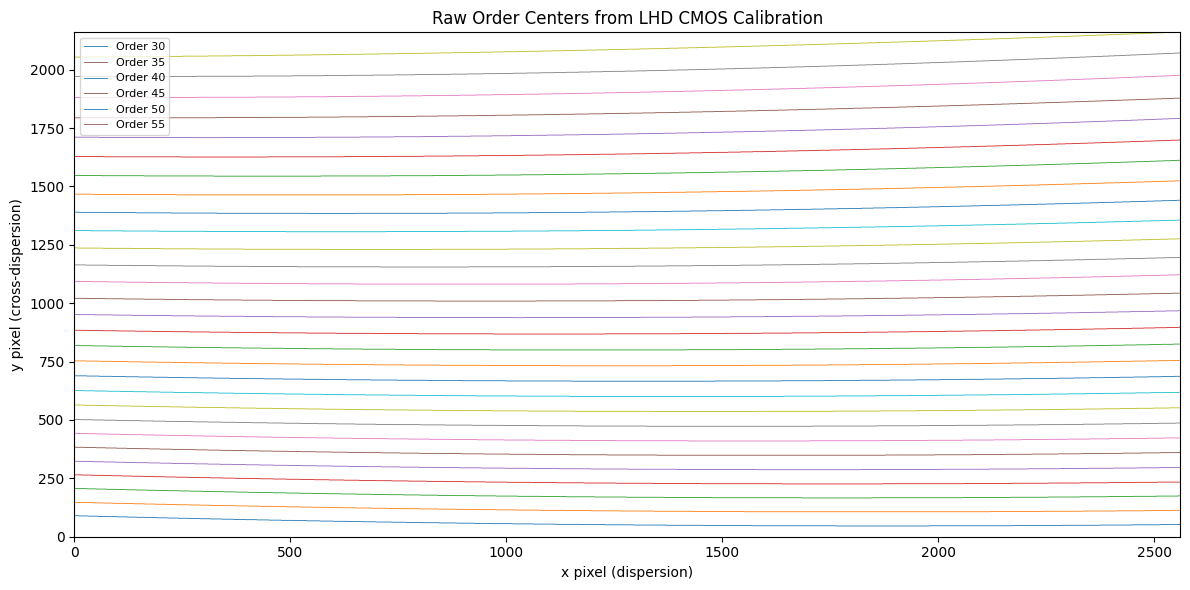

In [2]:
x_pixels, traces_raw = load_lhd_cmos_pattern()

fig, ax = plt.subplots(figsize=(12, 6))
for i in range(traces_raw.shape[1]):
    ax.plot(x_pixels, traces_raw[:, i], lw=0.6, label=f"Order {30+i}" if i % 5 == 0 else "")

ax.set_xlabel("x pixel (dispersion)")
ax.set_ylabel("y pixel (cross-dispersion)")
ax.set_title("Raw Order Centers from LHD CMOS Calibration")
ax.legend(loc="upper left", fontsize=8)
ax.set_xlim(0, 2560)
ax.set_ylim(0, 2160)
plt.tight_layout()
plt.show()

## 2. Fitted Traces and Residuals

Fit quadratic polynomials to each order trace and inspect the fit quality.

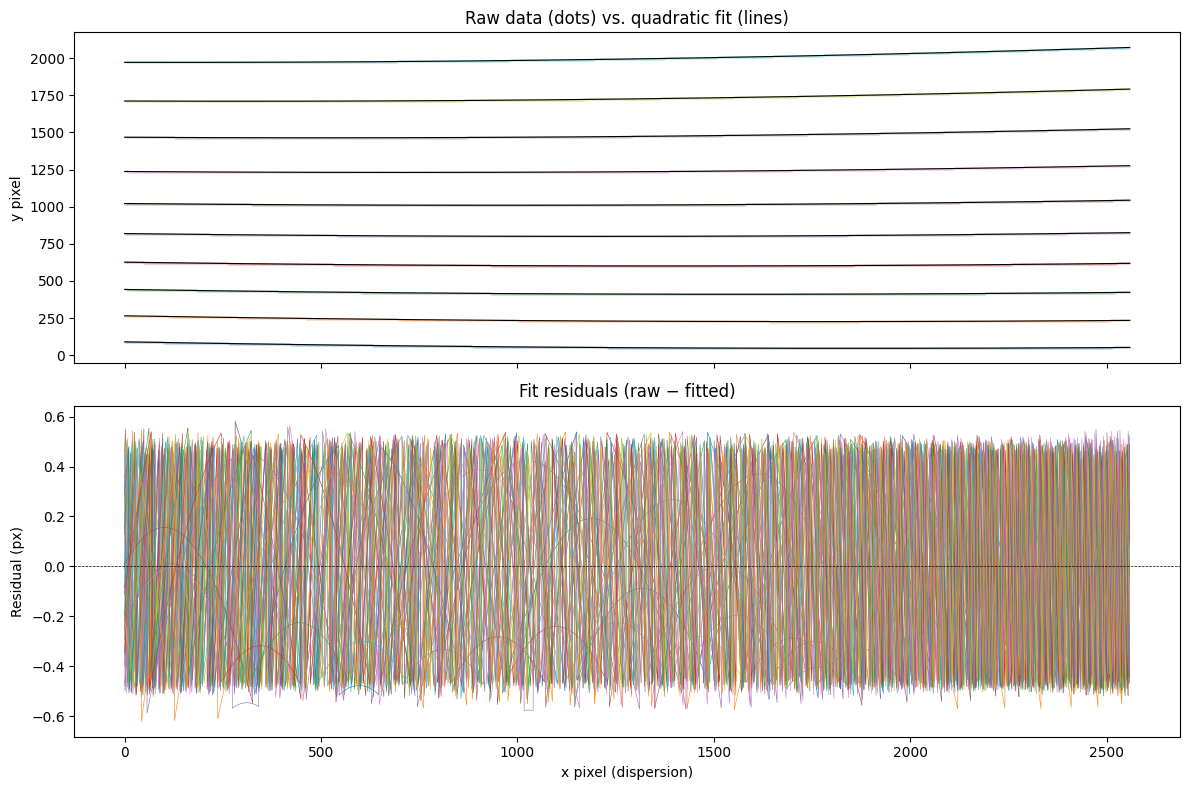

RMS residuals: min=0.277 px, max=0.304 px, mean=0.293 px


In [3]:
geom = load_lhd_cmos_geometry(poly_degree=2)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax = axes[0]
for trace in geom.traces[::3]:
    ax.plot(trace.x_pixels, trace.y_raw, '.', ms=0.3, alpha=0.4)
    ax.plot(trace.x_pixels, trace.y_fitted, 'k-', lw=0.8)
ax.set_ylabel("y pixel")
ax.set_title("Raw data (dots) vs. quadratic fit (lines)")

ax = axes[1]
for trace in geom.traces:
    ax.plot(trace.x_pixels, trace.residuals, lw=0.4)
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel("x pixel (dispersion)")
ax.set_ylabel("Residual (px)")
ax.set_title("Fit residuals (raw − fitted)")

plt.tight_layout()
plt.show()

# Print RMS residuals
rms_all = [np.sqrt(np.mean(t.residuals**2)) for t in geom.traces]
print(f"RMS residuals: min={min(rms_all):.3f} px, max={max(rms_all):.3f} px, "
      f"mean={np.mean(rms_all):.3f} px")

## 3. Order Curvature Visualization

Show the deviation of each trace from a straight line (its mean y value)
to highlight the curvature magnitude.

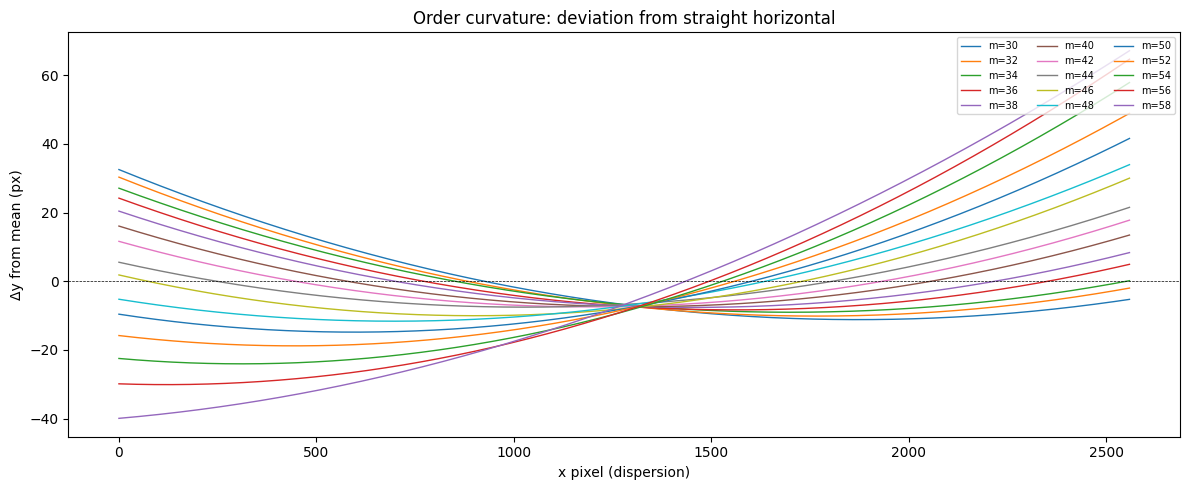

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

for trace in geom.traces[::2]:
    y_mean = trace.y_fitted.mean()
    curvature = trace.y_fitted - y_mean
    ax.plot(trace.x_pixels, curvature, lw=1.0, label=f"m={trace.order}")

ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel("x pixel (dispersion)")
ax.set_ylabel("Δy from mean (px)")
ax.set_title("Order curvature: deviation from straight horizontal")
ax.legend(loc="upper right", fontsize=7, ncol=3)
plt.tight_layout()
plt.show()

## 4. Side-by-Side: Ideal Straight vs. Measured Curved

Render the same white-light continuum with both geometry modes and compare.

In [5]:
# Ideal straight orders
img_ideal = render_white_light(
    spec, orders, shape=SHAPE,
    order_spacing_px=65.0, psf_sigma_y_px=12.0,
    color=True, geometry=GeometryMode.IDEAL_STRAIGHT,
)

# Measured curved orders
img_curved = render_white_light(
    spec, orders, shape=SHAPE,
    psf_sigma_y_px=12.0,
    color=True, geometry=GeometryMode.MEASURED_LHD_CMOS,
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000147].


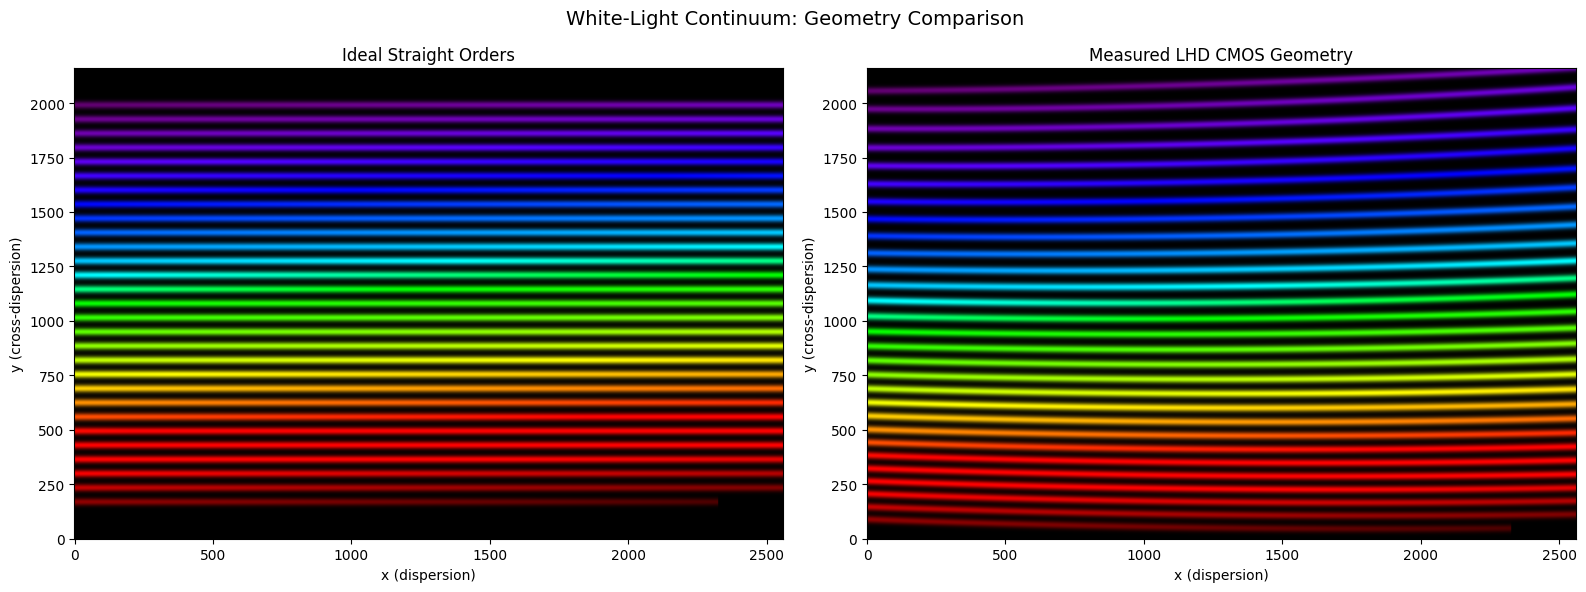

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(img_ideal, origin="lower", aspect="auto")
axes[0].set_title("Ideal Straight Orders")
axes[0].set_xlabel("x (dispersion)")
axes[0].set_ylabel("y (cross-dispersion)")

axes[1].imshow(img_curved, origin="lower", aspect="auto")
axes[1].set_title("Measured LHD CMOS Geometry")
axes[1].set_xlabel("x (dispersion)")
axes[1].set_ylabel("y (cross-dispersion)")

plt.suptitle("White-Light Continuum: Geometry Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Zoomed Comparison

Zoom into a region to clearly see the curvature difference.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.000001].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0000013].


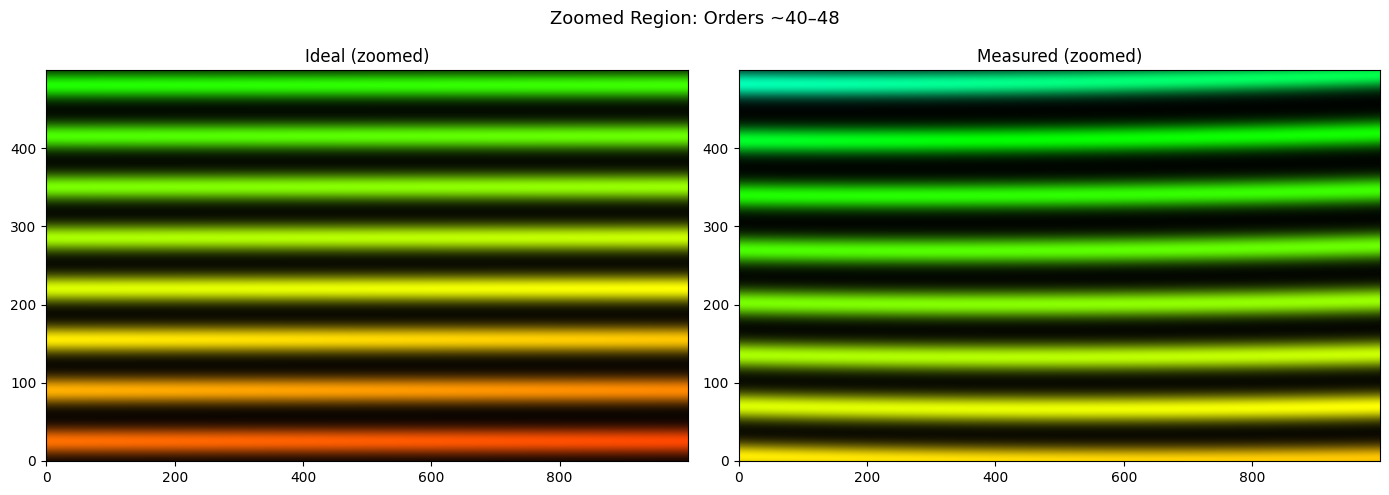

In [7]:
# Zoom into center region: orders 40-48, x ∈ [800, 1800]
y_slice = slice(600, 1100)
x_slice = slice(800, 1800)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(img_ideal[y_slice, x_slice], origin="lower", aspect="auto")
axes[0].set_title("Ideal (zoomed)")

axes[1].imshow(img_curved[y_slice, x_slice], origin="lower", aspect="auto")
axes[1].set_title("Measured (zoomed)")

plt.suptitle("Zoomed Region: Orders ~40–48", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Polynomial Coefficients

Display the fitted polynomial coefficients for all orders.

In [8]:
print(f"{'Order':>5} {'c0 (offset)':>12} {'c1 (slope)':>12} {'c2 (curvature)':>15}")
print("-" * 50)
for trace in geom.traces:
    c0, c1, c2 = trace.coefficients
    print(f"{trace.order:5d} {c0:12.3f} {c1:12.4f} {c2:15.6f}")

Order  c0 (offset)   c1 (slope)  c2 (curvature)
--------------------------------------------------
   30       50.700     -10.9114        6.810856
   31      110.343      -9.9466        6.596583
   32      169.475      -9.3257        7.081034
   33      229.165      -8.8930        6.903700
   34      289.507      -7.7770        6.814172
   35      350.128      -6.6235        7.319169
   36      411.257      -5.5627        7.282041
   37      473.707      -4.4370        6.913789
   38      536.702      -3.4859        7.191106
   39      600.906      -2.2267        7.148003
   40      666.106      -0.7551        7.379482
   41      732.234       0.4998        7.376132
   42      799.916       1.7809        7.351453
   43      868.676       3.5593        7.284526
   44      939.363       4.6137        6.762464
   45     1010.698       6.3806        7.188690
   46     1083.691       8.1364        7.963755
   47     1158.263       9.2350        7.275703
   48     1234.702      11.3139      

## Summary

Key observations:

1. **Order curvature is small but measurable** — typically a few pixels across
   the full detector width.

2. **Quadratic polynomials provide good fits** — sub-pixel RMS residuals for
   all orders.

3. **The curvature is an optical/geometry effect**, not a property of
   diffraction.  It arises from camera aberrations and image-plane projection.

4. **Both modes are supported by the renderer** — `GeometryMode.IDEAL_STRAIGHT`
   for idealized simulations, `GeometryMode.MEASURED_LHD_CMOS` for realistic
   detector geometry.